<a href="https://colab.research.google.com/github/vaniajou/Sistem-Peringatan-Dini-Kegagalan-Siswa/blob/main/SVM_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HASIL KLASIFIKASI SVM (KERNEL RBF)
              precision    recall  f1-score   support

           0       0.75      0.22      0.34        27
           1       0.42      0.94      0.58        32
           2       0.00      0.00      0.00        20

    accuracy                           0.46        79
   macro avg       0.39      0.39      0.31        79
weighted avg       0.43      0.46      0.35        79



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


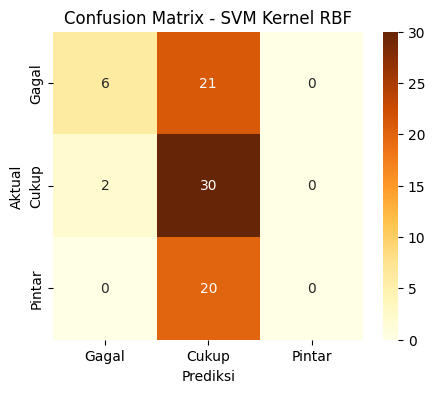

Akurasi Akhir SVM: 0.46


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_excel('Book1.xlsx')

def buat_label(nilai):
    if nilai <= 9: return 0
    elif nilai <= 14: return 1
    else: return 2

df['Label_Multi'] = df['G3'].apply(buat_label)
df_model = df.drop(['G1', 'G2', 'G3', 'Label_Multi'], axis=1)

le = LabelEncoder()
for col in df_model.columns:
    if df_model[col].dtype == 'object':
        df_model[col] = le.fit_transform(df_model[col])

X = df_model.values
y = df['Label_Multi'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
model_svm.fit(X_train_scaled, y_train)
y_pred_svm = model_svm.predict(X_test_scaled)

print("HASIL KLASIFIKASI SVM (KERNEL RBF)")
print(classification_report(y_test, y_pred_svm))

cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=['Gagal', 'Cukup', 'Pintar'],
            yticklabels=['Gagal', 'Cukup', 'Pintar'])
plt.title('Confusion Matrix - SVM Kernel RBF')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

print(f"Akurasi Akhir SVM: {accuracy_score(y_test, y_pred_svm):.2f}")